# ML modeling on MISO total load data (Sept. 2023 - June 2026)

In [1]:
# Adjust path so the notebook can be run natively in VSCode
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

# Import libraries
import pandas as pd
import numpy as np
import math
from app.database import engine

In [2]:
region_df = pd.read_sql("SELECT * FROM load_actuals;", con=engine)
region_df["timestamp"] = pd.to_datetime(region_df["timestamp"])

df = (
    region_df.groupby("timestamp", as_index=False)["load_mw"].sum()
    .sort_values("timestamp")
    .reset_index(drop=True)
)
df.head()

,timestamp,load_mw
0,2023-09-01 00:00:00,66603
1,2023-09-01 01:00:00,64302
2,2023-09-01 02:00:00,62909
3,2023-09-01 03:00:00,62500
4,2023-09-01 04:00:00,63063


In [3]:
def build_features(df: pd.DataFrame):
    df["lag_1h"] = df["load_mw"].shift(1)
    df["lag_2h"] = df["load_mw"].shift(2)
    df["lag_24h"] = df["load_mw"].shift(24)

    hour = df["timestamp"].dt.hour
    df["hour_sin"] = np.sin((2 * math.pi * hour) / 24)
    df["hour_cos"] = np.cos((2 * math.pi * hour) / 24)

    day_of_year = df["timestamp"].dt.dayofyear
    df["day_of_year_sin"] = np.sin((2 * math.pi * day_of_year) / 365.25)
    df["day_of_year_cos"] = np.cos((2 * math.pi * day_of_year) / 365.25)

    df["is_weekend"] = df["timestamp"].dt.dayofweek >= 5

In [4]:
build_features(df)

FEATURES = [
    "lag_1h", "lag_2h", "lag_24h",
    "hour_sin", "hour_cos",
    "day_of_year_sin", "day_of_year_cos",
    "is_weekend",
]
TARGET = "load_mw"

model_df = df.dropna(subset=FEATURES).reset_index(drop=True)  # drop rows with NaN lags
X = model_df[FEATURES]
y = model_df[TARGET]
print(f"{len(model_df)} rows, {len(FEATURES)} features")

24792 rows, 8 features


In [5]:
# Chronological split instead of random split for time series
split = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train):>6} rows through {model_df['timestamp'].iloc[split - 1]}")
print(f"Test:  {len(X_test):>6} rows from    {model_df['timestamp'].iloc[split]}")

Train:  19833 rows through 2025-12-06 08:00:00
Test:    4959 rows from    2025-12-06 09:00:00


In [6]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"{name:<18} MAE {mae:8.0f} MW   MAPE {mape:6.2%}")

# Baselines
report("persistence", y_test, model_df["lag_1h"].iloc[split:])
report("seasonal-naive", y_test, model_df["lag_24h"].iloc[split:])

# Model
model = HistGradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)
report("gradient boosting", y_test, model.predict(X_test))

persistence        MAE     1602 MW   MAPE  2.09%
seasonal-naive     MAE     3407 MW   MAPE  4.38%
gradient boosting  MAE      495 MW   MAPE  0.63%


## Per-horizon forecasts (1h / 3h / 6h)

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

CALENDAR = ["hour_sin", "hour_cos", "day_of_year_sin", "day_of_year_cos", "is_weekend"]
HORIZONS = [1, 3, 6]

def build_horizon_xy(frame, h):
    load = frame["load_mw"]
    feats = pd.DataFrame({
        "lag_h":   load.shift(h),      # load(T-h) — most recent load available at origin
        "lag_h1":  load.shift(h + 1),  # load(T-h-1)
        "lag_24h": load.shift(24),     # load(T-24) — same hour yesterday for h <= 24
    })
    feats[CALENDAR] = frame[CALENDAR]
    y = load
    valid = feats.notna().all(axis=1) & y.notna()
    return feats[valid], y[valid]

def evaluate_horizon(frame, h):
    Xh, yh = build_horizon_xy(frame, h)
    split = int(len(Xh) * 0.8)
    X_tr, X_te = Xh.iloc[:split], Xh.iloc[split:]
    y_tr, y_te = yh.iloc[:split], yh.iloc[split:]

    model = HistGradientBoostingRegressor(random_state=42).fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return {
        "h": h,
        "persistence": mean_absolute_percentage_error(y_te, X_te["lag_h"]),      # load(T-h)
        "seasonal_naive": mean_absolute_percentage_error(y_te, X_te["lag_24h"]), # load(T-24)
        "model": mean_absolute_percentage_error(y_te, preds),
        "model_mae": mean_absolute_error(y_te, preds),
    }

results = [evaluate_horizon(df, h) for h in HORIZONS]

print(f"{'horizon':>7} {'persist':>9} {'seasonal':>9} {'model':>9} {'model MAE':>11} {'skill vs sn':>12}")
for r in results:
    skill = 1 - r["model"] / r["seasonal_naive"]
    print(f"{r['h']:>6}h {r['persistence']:>8.2%} {r['seasonal_naive']:>8.2%} "
          f"{r['model']:>8.2%} {r['model_mae']:>8.0f} MW {skill:>11.1%}")

horizon   persist  seasonal     model   model MAE  skill vs sn
     1h    2.09%    4.38%    0.63%      495 MW       85.6%
     3h    5.89%    4.38%    1.94%     1526 MW       55.8%
     6h    9.90%    4.38%    3.09%     2461 MW       29.4%


## Forecast example

Actual load over a held-out test window, with each horizon's forecast overlaid

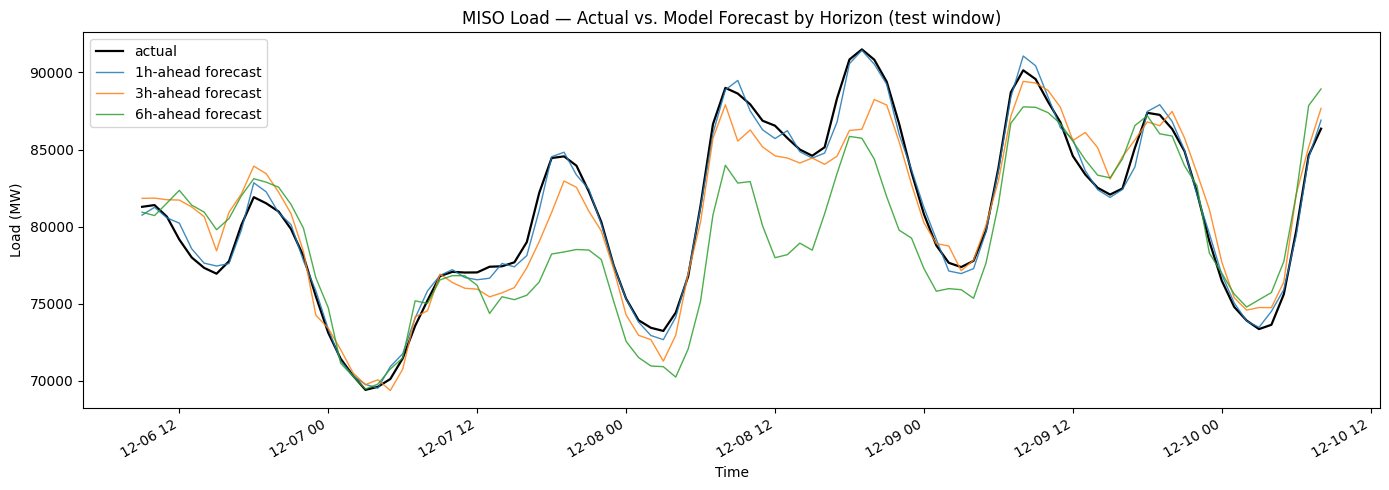

In [8]:
import matplotlib.pyplot as plt

# Refit each horizon
forecasts = {}
for h in HORIZONS:
    Xh, yh = build_horizon_xy(df, h)
    split = int(len(Xh) * 0.8)
    model = HistGradientBoostingRegressor(random_state=42).fit(Xh.iloc[:split], yh.iloc[:split])
    X_te, y_te = Xh.iloc[split:], yh.iloc[split:]
    forecasts[h] = pd.Series(model.predict(X_te), index=X_te.index)

# Plot a few days of the test set
WINDOW = 96  # hours to display
idx = y_te.index[:WINDOW]
t = df.loc[idx, "timestamp"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t, y_te.loc[idx], label="actual", color="black", linewidth=1.6)
for h in HORIZONS:
    ax.plot(t, forecasts[h].loc[idx], linewidth=1.0, alpha=0.85, label=f"{h}h-ahead forecast")

ax.set_title("MISO Load — Actual vs. Model Forecast by Horizon (test window)")
ax.set_xlabel("Time")
ax.set_ylabel("Load (MW)")
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.show()

The 1h forecast tracks actual loads closely. Longer horizons smooth out and degrade in accuracy.